# data generation for this script
## Synthtab
run the scripts:
* python/neuralnetmodelling/synthtab_dataprep-nofilter.ipynb for generation of the label slices, tagged with metadata regarding the audio files
* python/neuralnetmodelling/create_trainingsubset.ipynb, to generate a subset of the labels with their prefiltered audio snippets

# run this headless

conda activate guitarmidi
screen jupyter nbconvert --to notebook --execute traning.ipynb --output=output_notebook.ipynb --ExecutePreprocessor.timeout=-1



In [12]:
import re
import os
file='/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset/filtered_poly_data_03614.tfrecord'

int(re.findall('\\d+',os.path.basename(file))[0])



3614

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
# NO Keras backend import needed now

import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES,feature_description
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import random

input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/'#'/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training'
input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '**', '*.tfrecord'), recursive=True),key=lambda file: int(re.findall('\\d+',os.path.basename(file))[0]) )
print(input_filepaths)
# input_filepaths=input_filepaths[:2]

random.shuffle(input_filepaths)

input_record="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data.tfrecord"

#Load the dataset from the TFRecord file
raw_dataset = tf.data.TFRecordDataset(input_filepaths)
# Function to parse the TFRecord examples
def parse_example(example_proto):
    return tf.io.parse_single_example(example_proto, feature_description)
# Parse the dataset
dataset = raw_dataset.map(parse_example).shuffle(buffer_size=10000,reshuffle_each_iteration=True)

print(dataset)
# Split the dataset into training and validation sets
#dataset_size =sum(1 for _ in dataset)
#dataset_size=605286
#dataset_size=2140000
dataset_size=10676000
print("The size is fixed to {dataset_size} for now, as counting the dataset size is time-consuming.")
print("Total dataset size:", dataset_size)
#dataset=dataset.shuffle(buffer_size=10000,reshuffle_each_iteration=True)#.shuffle(buffer_size=dataset_size)
split_ratio = 0.7
train_size = int(split_ratio * dataset_size)
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)



['/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_00000.tfrecord', '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_00001.tfrecord', '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_00002.tfrecord', '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_00003.tfrecord', '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_00004.tfrecord', '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_00005.tfrecord', '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_00006.tfrecord', '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_00007.tfrecord', '/home/gerald/workspace/src/Gui

In [14]:
output_range=range(40,84)
print(len(output_range))

44


Model Architecture:
--------------------------------------------------------------------------------
Model: "functional_2"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (64, 148, 256, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_6 (Reshape) │ (64, 148, 256, 1) │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (64, 148, 32, 16) │        272 │ reshape_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (64, 148, 32, 16) │         64 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │       

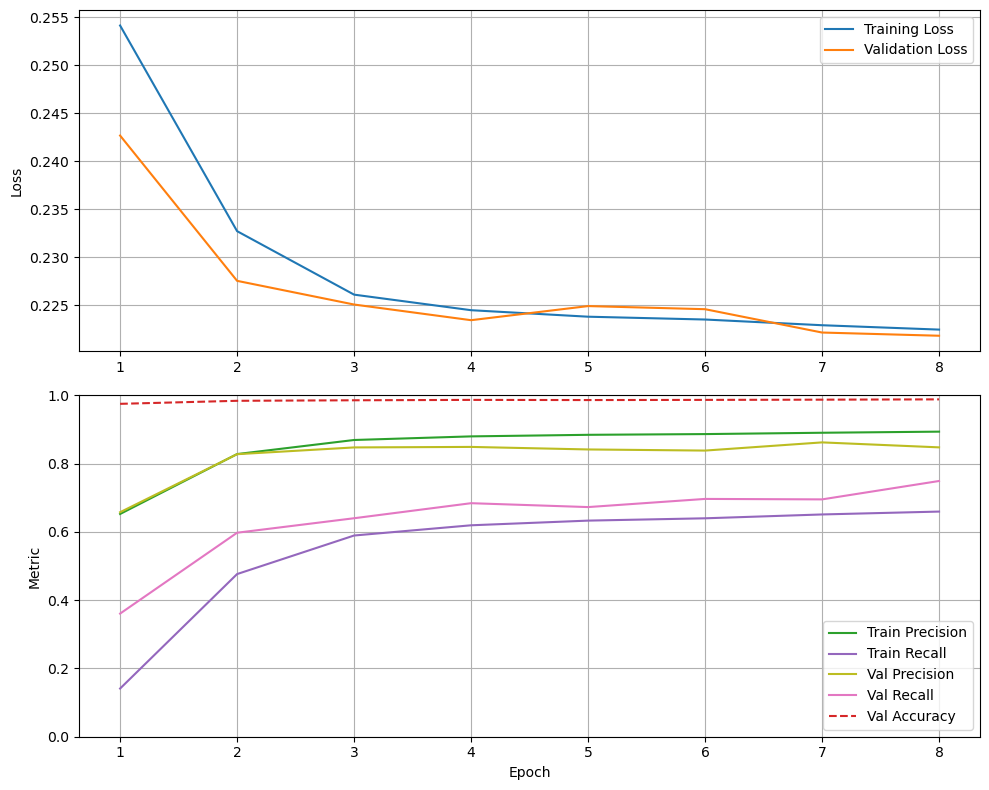

116768/116768 ━━━━━━━━━━━━━━━━━━━━ 1222s 10ms/step - bin_acc: 0.9876 - f1_score: 0.7564 - loss: 0.2225 - precision: 0.8940 - recall: 0.6598 - val_bin_acc: 0.9886 - val_f1_score: 0.7943 - val_loss: 0.2218 - val_precision: 0.8479 - val_recall: 0.7494 - learning_rate: 0.0010
Epoch 9/500
116761/116768 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - bin_acc: 0.9879 - f1_score: 0.7618 - loss: 0.2220 - precision: 0.8966 - recall: 0.6664

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
# NO Keras backend import needed now
from model import build_1d_cnn_model # Assumes build_cnn_model is in model.py
import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES,tf_load_sample_from_files,SAMPLERATE,feature_description,INPUT_SHAPE_AUDIO
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import datetime
from fretboard import FretBoard,num_frets,num_strings,num_harmonics
from scipy import signal
# --- 1. GPU Setup ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable Mixed Precision
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")

        for gpu in gpus:
            # Enable memory growth
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
# ---------------------------------------------------------------------------------

print(f"TensorFlow version: {tf.__version__}")

# --- 2. Configuration ---
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 500
print("Batch size:",BATCH_SIZE)
print("Learning rate:",LEARNING_RATE)
print("Epochs:",EPOCHS)
SAMPLES=dataset_size#
#SAMPLES=504000000000/(312*256+129) # Rough estimate of total samples in dataset
print("Estimated total samples:",SAMPLES)
STEPS_PER_EPOCH = int(SAMPLES // BATCH_SIZE)
print("Steps per epoch:",STEPS_PER_EPOCH)


VALIDATION_STEPS = int((SAMPLES * (1 - split_ratio)) // BATCH_SIZE)
print("Validation steps:",VALIDATION_STEPS)
output_range=range(40,84)
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training/output'
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'


# --- 4. Model Definition and Compilation (Using built-in loss) ---

# cnn_model = build_cnn_model(common.INPUT_SHAPE, common.OUTPUT_DIM_NOTES)
cnn_model = build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE, len(output_range))#common.OUTPUT_DIM_NOTES)
#load the file note_histogram.csv and create a weight vector for the loss function. Normalize the weights such that the silence label at OUTPUT_DIM_NOTES-1 has a weight of 1.0
import csv
weights = np.ones(OUTPUT_DIM_NOTES, dtype=np.float32)  # Default weights
with open(os.path.join('/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/note_histogram.csv'), mode='r') as csv_file:
    reader = csv.DictReader(csv_file)
    for row in reader:
        note = int(row['MIDI Note'])
        count = int(row['Count'])
        if count > 0 and note >= 40:  # Avoid division by zero and ignore very low notes
            weights[note] = 1.0 / count  # Inverse frequency weighting
        else:
            weights[note] = 0.0  # If a note never occurs, give it zero weight to avoid NaNs
# Normalize weights so that the max weight (for the least frequent note) is 1.0
# Normalize weights so the Silence label (last index) is the baseline (1.0)
silence_weight = weights[OUTPUT_DIM_NOTES - 1]
if silence_weight > 0:
    weights = weights / silence_weight
else:
    # Fallback if silence wasn't in the histogram for some reason
    weights = weights / np.mean(weights[weights > 0])

# Final Safety Clip: Don't let any note be more than 50x the weight of silence
weights = np.clip(weights, 0.0, 2.0)
weights=weights[output_range]

#weights=weights[60:80]


print("Class weights for loss function:", weights)
# define the weighted binary cross-entropy loss function using the weights, using label smoothing
def get_guitar_focal_loss(gamma=5.0, alpha=0.25):
    # Ensure weights are (1, 129) for proper broadcasting across the batch
    note_weights = tf.constant(weights, dtype=tf.float32)
    note_weights = tf.reshape(note_weights, (1, -1)) 
    
    def loss_fn(y_true, y_pred):
        # 1. Clip predictions to prevent log(0) resulting in NaN
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        # 2. Calculate standard Binary Cross Entropy per-element
        # Shape: (Batch, 129)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        
        # 3. Calculate Focal Term: (1 - p_t)^gamma
        # p_t is y_pred for actual notes, and (1 - y_pred) for silence
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        focal_factor = tf.pow(1.0 - p_t, gamma)
        
        # 4. Calculate Alpha Balancing: 
        alpha_factor = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        
        # 5. Combine everything with your CSV-based note weights
        # (Batch, 129) * (Batch, 129) * (Batch, 129) * (1, 129)
        element_wise_loss = alpha_factor * focal_factor * bce * note_weights
        
        # 6. Reduce to a single scalar (mean of all batch elements and all notes)
        return tf.reduce_mean(element_wise_loss)

    return loss_fn

cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    #loss=get_guitar_focal_loss(),#
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1), # Pass the class weights here
    #loss=tf.keras.losses.BinaryFocalCrossentropy(apply_class_balancing=True,gamma=3.0,label_smoothing=0.1),#,alpha=0.75, gamma=5.0, label_smoothing=0.0), # Focal loss with class balancing and label smoothing
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='bin_acc'), # Measures individual bit correctness
        tf.keras.metrics.Precision(name='precision'), 
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.F1Score(average='weighted', threshold=0.5)
    ],
    jit_compile=True
)

cnn_model.summary()


# --- 5. Custom Callback for Live Loss Plotting (omitted for brevity, assume definition remains the same) ---
class PlotLoss(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.losses = []
        self.val_losses = []
        self.acc = []
        self.val_bin_acc = []
        # New: precision & recall tracking
        self.precision = []
        self.val_precision = []
        self.recall = []
        self.val_recall = []
        self.epochs_run = []
        self.fig, (self.ax_loss, self.ax_acc) = plt.subplots(2, 1, figsize=(10, 8))
        # Save model summary to string
        summary_list = []
        self.model.summary(print_fn=lambda x: summary_list.append(x))
        self.model_summary = '\n'.join(summary_list)

        # Save summary to file
        with open('model_summary.txt', 'w') as f:
            f.write(self.model_summary)

    def on_epoch_end(self, epoch, logs=None):
        # local import so notebook output display works even when executed headless
        from IPython.display import display, Image, clear_output

        logs = logs or {}
        self.epochs_run.append(epoch + 1)

        # safe conversion to numbers (use NaN if missing)
        self.losses.append(float(logs.get('loss')) if logs.get('loss') is not None else np.nan)
        self.val_losses.append(float(logs.get('val_loss')) if logs.get('val_loss') is not None else np.nan)

        # support both 'accuracy' and 'acc' keys
        acc_val = logs.get('accuracy') if 'accuracy' in logs else logs.get('acc')
        val_bin_acc_val = logs.get('val_bin_acc') if 'val_bin_acc' in logs else logs.get('val_bin_acc')
        self.acc.append(float(acc_val) if acc_val is not None else np.nan)
        self.val_bin_acc.append(float(val_bin_acc_val) if val_bin_acc_val is not None else np.nan)

        # New: precision & recall (training and validation)
        prec = logs.get('precision') if 'precision' in logs else logs.get('precision')
        val_prec = logs.get('val_precision') if 'val_precision' in logs else logs.get('val_precision')
        rec = logs.get('recall') if 'recall' in logs else logs.get('recall')
        val_rec = logs.get('val_recall') if 'val_recall' in logs else logs.get('val_recall')
        self.precision.append(float(prec) if prec is not None else np.nan)
        self.val_precision.append(float(val_prec) if val_prec is not None else np.nan)
        self.recall.append(float(rec) if rec is not None else np.nan)
        self.val_recall.append(float(val_rec) if val_rec is not None else np.nan)

        # clear previous cell output, draw and save figure, then display saved PNG so it remains in notebook
        clear_output(wait=True)
        # Print model summary first
        print("Model Architecture:")
        print("-" * 80)
        print(self.model_summary)
        print("-" * 80)

        # Loss subplot
        self.ax_loss.clear()
        self.ax_loss.plot(self.epochs_run, self.losses, label='Training Loss', color='tab:blue')
        if any(~np.isnan(self.val_losses)):
            self.ax_loss.plot(self.epochs_run[:len(self.val_losses)], self.val_losses, label='Validation Loss', color='tab:orange')
        self.ax_loss.set_ylabel('Loss')
        self.ax_loss.legend(loc='upper right')
        self.ax_loss.grid(True)

        # Metrics subplot: Precision & Recall (+ optional accuracy)
        self.ax_acc.clear()
        # Plot training precision & recall
        self.ax_acc.plot(self.epochs_run, self.precision, label='Train Precision', color='tab:green')
        self.ax_acc.plot(self.epochs_run, self.recall, label='Train Recall', color='tab:purple')
        # Optionally include accuracy if available
        if any(~np.isnan(self.acc)):
            self.ax_acc.plot(self.epochs_run, self.acc, label='Train Accuracy', color='tab:gray', linestyle='--')

        # Plot validation metrics if present
        if any(~np.isnan(self.val_precision)):
            self.ax_acc.plot(self.epochs_run[:len(self.val_precision)], self.val_precision, label='Val Precision', color='tab:olive')
        if any(~np.isnan(self.val_recall)):
            self.ax_acc.plot(self.epochs_run[:len(self.val_recall)], self.val_recall, label='Val Recall', color='tab:pink')
        if any(~np.isnan(self.val_bin_acc)):
            self.ax_acc.plot(self.epochs_run[:len(self.val_bin_acc)], self.val_bin_acc, label='Val Accuracy', color='tab:red', linestyle='--')

        self.ax_acc.set_xlabel('Epoch')
        self.ax_acc.set_ylabel('Metric')
        self.ax_acc.set_ylim(0.0, 1.0)
        self.ax_acc.legend(loc='lower right')
        self.ax_acc.grid(True)

        self.fig.tight_layout()
        self.fig.savefig("training.png", bbox_inches='tight')  # persist image
        display(Image("training.png"))  # embed PNG in notebook output so it remains visible
        plt.close(self.fig)  # close to free memory; will recreate on next epoch

# --- 6. Data Loading and Preparation (Modified to include weights) ---

print(f"Found {dataset_size} files on disk.")









def fast_gpu_map(parsed,training=True):
# 1. Decoding and Basic Setup
    input_raw = tf.io.decode_raw(parsed["input"], tf.int8)
    label_raw = tf.io.decode_raw(parsed["output"], tf.int8)
    
    input_tensor = tf.reshape(input_raw, INPUT_SHAPE)
    input_tensor = tf.cast(input_tensor, tf.float32)
    input_tensor=input_tensor/127
    output_tensor = tf.cast(tf.reshape(label_raw, [OUTPUT_DIM_NOTES]), tf.float32)
    
    # Constants for clarity
    SILENCE_IDX = OUTPUT_DIM_NOTES - 1
    silence_vector = tf.one_hot(SILENCE_IDX, depth=OUTPUT_DIM_NOTES, dtype=tf.float32)
    zero_input = tf.zeros_like(input_tensor)

    # 2. Extract Logic Components
    # Identify if any actual notes are active (indices 0 to 87)
    note_labels = output_tensor[:SILENCE_IDX]
    any_notes_active = tf.reduce_any(tf.greater(note_labels, 0.5))
    
    # Check current states
    silence_label_is_up = tf.greater(output_tensor[SILENCE_IDX], 0.5)
    max_en=tf.reduce_max(tf.abs(input_tensor)) 
    energy_is_low = max_en< 0.01
    # if ~energy_is_low:
    #     input_tensor/=max_en
    # 3. The "Vice Versa" Logic
    # We "Force Silence" if: 
    # - Energy is low OR 
    # - The silence label was already up OR 
    # - No notes are active
    should_force_silence = energy_is_low | silence_label_is_up | (~any_notes_active)

    # Apply transformations
    output_tensor = tf.where(should_force_silence, silence_vector, output_tensor)
    output_tensor=output_tensor[40:84]
    input_tensor = tf.where(should_force_silence, zero_input, input_tensor)

    # 4. Augmentation (Only if we aren't in a forced silence state)
    if training:
        noise = tf.random.normal(shape=tf.shape(input_tensor), mean=0.0, stddev=0.01)
        # We only add noise to frames that actually have content to avoid 
        # teaching the model that "noise = note"
        input_tensor = tf.where(should_force_silence, zero_input, input_tensor + noise)
        input_tensor = tf.clip_by_value(input_tensor, -1.0, 1.0)
        num_masks = 2
        mask_width = 5 # How many filter bins to hide
        for _ in range(num_masks):
            start = tf.random.uniform([], 0, INPUT_SHAPE[0] - mask_width, dtype=tf.int32)
            indices = tf.range(start, start + mask_width)
            # Create a mask of 1s, then set the specific indices to 0
            mask = tf.one_hot(indices, depth=INPUT_SHAPE[0])
            mask = 1.0 - tf.reduce_sum(mask, axis=0)
            mask = tf.reshape(mask, (INPUT_SHAPE[0],1, 1))
            input_tensor = input_tensor * mask

    return input_tensor, output_tensor



# Map loading function (now includes the weight vector)

train_dataset = train_dataset.map(lambda path: fast_gpu_map(path, training=True), num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(lambda path: fast_gpu_map(path, training=False), num_parallel_calls=tf.data.AUTOTUNE)




# # Apply batching and prefetching  (use train/val_dataset.cache().batch... if needed)
train_dataset = train_dataset.batch(BATCH_SIZE,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE,drop_remainder=True).prefetch(tf.data.AUTOTUNE)
# train_dataset = batch_with_weights(train_dataset).prefetch(tf.data.AUTOTUNE)
# val_dataset = batch_with_weights(val_dataset).prefetch(tf.data.AUTOTUNE)

# --- 7. Training the Model (Passing the element-wise weight) ---

plot_callback = PlotLoss()
early_stopping_callback = EarlyStopping(
    monitor='val_recall', 
    patience=20,   
    min_delta=0.000001, 
    mode='max',          
    verbose=1,           
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_recall',
    factor=0.2,
    patience=10,
    min_lr=1e-6,
    verbose=1
)
# Use a custom learning rate scheduler
def lr_scheduler(epoch, lr):
    warmup_epochs = 5
    max_lr = 0.001
    
    if epoch < warmup_epochs:
        # Gradually increase LR from 1e-5 to 1e-3
        return 1e-5 + (max_lr - 1e-5) * (epoch / warmup_epochs)
    else:
        # Cosine Decay or stick to 1e-3 until plateau
        return max_lr

lr_scheduler_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)
checkpoint=ModelCheckpoint('checkpoints/guitarmidi_epoch{epoch:02d}_valAcc{val_bin_acc:.4f}_valPrec{val_precision:.4f}_valRecall{val_recall:.4f}.weights.h5', save_weights_only=True,save_freq='epoch')
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,
        histogram_freq=1,  # Log weight histograms every epoch
        write_graph=True,
        write_images=True,
        update_freq='epoch',
        profile_batch='10,20',  # Profile batches 10-20 for performance analysis
        embeddings_freq=1)
# initial_learning_rate = LEARNING_RATE
# warmup_epochs = 5

# class WarmUpLearningRateScheduler(tf.keras.callbacks.Callback):
#     def __init__(self, warmup_epochs, initial_lr):
#         super().__init__()
#         self.warmup_epochs = warmup_epochs
#         self.initial_lr = initial_lr
        
#     def on_epoch_begin(self, epoch, logs=None):
#         if epoch < self.warmup_epochs:
#             lr = self.initial_lr * ((epoch + 1) / self.warmup_epochs)
#             tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)
#             print(f'\nEpoch {epoch+1}: WarmUp LR set to {lr}')

# warmup = WarmUpLearningRateScheduler(warmup_epochs, initial_learning_rate)

print("\n--- Starting CNN Model Training with Sample Weights ---")
try:

   # cnn_model.load_weights('/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_epoch09_valAcc0.9895_valPrec0.8458_valRecall0.4866.weights.h5');
    # Keras expects (features, labels, sample_weights) when sample_weights are present
    
    history_cnn = cnn_model.fit(train_dataset,
                                # initial_epoch=9,
                                epochs=EPOCHS,
                                # steps_per_epoch=STEPS_PER_EPOCH,
                                # validation_steps=VALIDATION_STEPS,
                                #batch_size=BATCH_SIZE, shuffle=False,
                                validation_data=val_dataset,
                                callbacks=[plot_callback, early_stopping_callback,checkpoint,reduce_lr,tensorboard_callback,lr_scheduler_callback])
    
    cnn_model.save_weights('guitarmidi.weights.h5')
    print("Model weights saved successfully!")
    
except Exception as e:
    print(f"An error occurred during training: {e}")

In [ ]:
from tensorflow.data import Dataset
dataset = Dataset.range(1, 6)  # ==> [ 1, 2, 3, 4, 5 ]
# NOTE: New lines indicate "block" boundaries.
dataset = dataset.interleave(
  lambda x: Dataset.from_tensors(x).repeat(6),
    cycle_length=2, block_length=4)
list(dataset.as_numpy_iterator())

In [ ]:
# import os
# os.system("sleep 10")
# os.system("poweroff")